# 02 — Leakage audit

**This notebook protects the study.** It decides what is admissible as a feature, and a mistake here would invalidate every result downstream while producing no error message.

Three questions:

1. **Is `isFlaggedFraud` an input or an output?** Lokanan dropped it for having "no variation." The stronger reason is that it is the simulator's own rule evaluated against the label — information no live system holds at scoring time.
2. **Which features encode the simulator rather than the behaviour?** A depth-1 stump per feature, scored out of sample. Anything that separates the classes nearly perfectly on its own is an artifact, not a discovery.
3. **How much of the achievable performance rests on those artifacts?** Whatever the answer, every headline result in notebooks 03–06 is produced twice — with and without them — so the report can state that conclusions survive their removal.

The proposal anticipates exactly this in §3.4: *"models must be rigorously assessed to ensure they do not overfit to the simulator's specific internal dynamics."*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import analysis as A
from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import splits as S
from momo_fraud import viz
from momo_fraud.features import ARTIFACT_FEATURES, FeatureBuilder

viz.apply_house_style()
df = D.load()
print(f"{len(df):,} transactions loaded")

6,362,620 transactions loaded


## 1. `isFlaggedFraud` is an output, not an input

If this column fires only on transactions that are genuinely fraudulent, it cannot be a *predictor* of fraud — it is a downstream consequence of knowing the answer. Precision against the label settles it.

In [2]:
evidence = A.flagged_fraud_evidence(df)
for key, value in evidence.items():
    print(f"  {key:26s} {value:,.6f}" if isinstance(value, float) else f"  {key:26s} {value:,}")

E.save_json(evidence, "02_flagged_fraud_evidence")

print(f"\nVerdict: dropped. It fires on {evidence['n_flagged']} transactions "
      f"({evidence['share_of_dataset']:.7%} of the dataset) and recovers only "
      f"{evidence['recall_against_label']:.2%} of fraud, so it is useless as a feature\n"
      f"even before the leakage argument — but the leakage argument is the reason.")

  n_flagged                  16
  n_flagged_and_fraud        16
  precision_against_label    1.000000
  recall_against_label       0.001948
  share_of_dataset           0.000003

Verdict: dropped. It fires on 16 transactions (0.0002515% of the dataset) and recovers only 0.19% of fraud, so it is useless as a feature
even before the leakage argument — but the leakage argument is the reason.


## 2. The simulator's fingerprints

Two bookkeeping properties of PaySim that a real mobile money ledger would not share:

- **The drain signature** — fraud agents empty the account, so `amount == oldbalanceOrg`.
- **The uncredited destination** — the simulator does not credit the receiving account on fraudulent transfers, so both destination balances stay at zero.

In [3]:
drain = A.drain_signature(df)
zeros = A.zero_balance_rates(df)

E.save_results(drain.to_dict("records"), "02_drain_signature")
E.save_results(zeros.to_dict("records"), "02_zero_balance_rates")

display(drain)
display(zeros)

,class,n,fraction_amount_equals_balance,median_absolute_gap
0,legitimate,6354407,0.000013,112778.148438
1,fraud,8213,0.978205,0.000000


,condition,rate_legitimate,rate_fraud
0,origin_zero_before,0.330858,0.004992
1,origin_zero_after,0.566774,0.980519
2,dest_zero_before,0.424750,0.651528
3,dest_zero_after,0.383252,0.498113
4,dest_zero_both,0.364032,0.496286


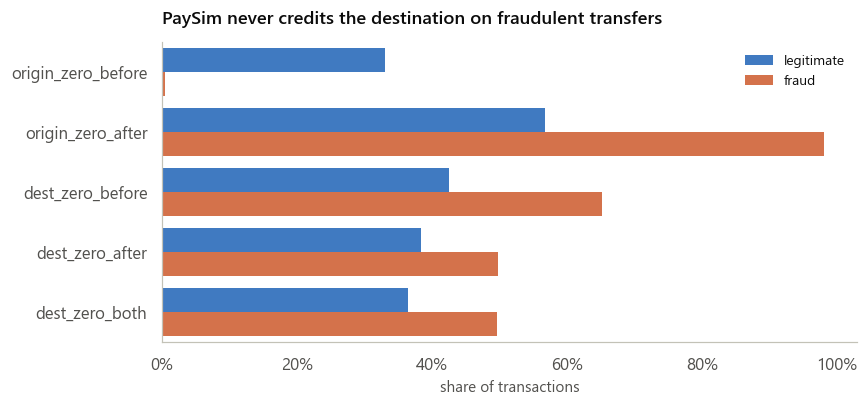

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))

long = zeros.melt(id_vars="condition", var_name="class", value_name="rate")
long["class"] = long["class"].str.replace("rate_", "", regex=False)

sns.barplot(long, x="rate", y="condition", hue="class",
            palette=viz.CLASS_COLORS, ax=ax)
ax.set(title="PaySim never credits the destination on fraudulent transfers",
       xlabel="share of transactions", ylabel="")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(title="")
viz.despine(ax)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "02_zero_balance_rates")
plt.show()

## 3. Is this a learning problem at all?

The single-feature probe below asks which columns carry signal. This asks something more fundamental: **can the label be reproduced by a handful of boolean clauses?**

PaySim's fraud agents follow a deterministic script — take over an account, transfer the full balance out, cash it out. If that script is expressible over the raw columns, then the dataset does not pose a classification problem so much as a lookup, and any model scoring highly on it may simply have rediscovered the generator.

This number belongs beside every model result in this study.

In [5]:
rules = A.rule_recoverability(df)
E.save_results(rules.to_dict("records"), "02_rule_recoverability")

best = rules.iloc[-1]
print(f"Strictest rule: {best['rule']}")
print(f"  flags {best['n_flagged']:,} of {len(df):,} transactions")
print(f"  precision {best['precision']:.4%}   recall {best['recall']:.4%}")
print()
print("Compare against published ML results on this same dataset:")
for name, value in C.THAR_WAI_PR_AUC.items():
    print(f"  Thar & Wai (2025) {name:22s} PR-AUC {value:.4f}")
rules

Strictest rule: risky type AND drained AND emptied
  flags 8,025 of 6,362,620 transactions
  precision 99.9875%   recall 97.6988%

Compare against published ML results on this same dataset:
  Thar & Wai (2025) logistic_regression    PR-AUC 0.7120
  Thar & Wai (2025) random_forest          PR-AUC 0.8905
  Thar & Wai (2025) xgboost                PR-AUC 0.9160
  Thar & Wai (2025) hmm                    PR-AUC 0.7050
  Thar & Wai (2025) hybrid_hmm_xgboost     PR-AUC 0.9689


,rule,n_flagged,precision,recall
0,"type in (TRANSFER, CASH_OUT)",2770409,0.002965,1.000000
1,amount == oldbalanceOrg,8115,0.990018,0.978205
2,risky type AND drained,8039,0.999378,0.978205
3,risky type AND drained AND emptied,8025,0.999875,0.976988


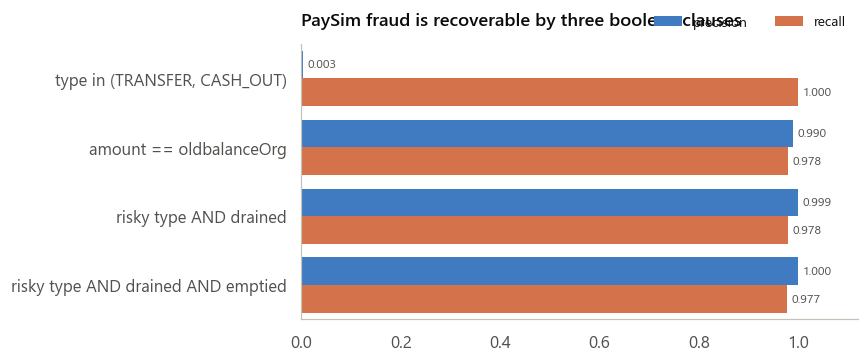

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.4))

sns.barplot(rules.melt(id_vars="rule", value_vars=["precision", "recall"],
                       var_name="metric", value_name="value"),
            x="value", y="rule", hue="metric",
            palette=viz.CATEGORICAL[:2], ax=ax)
viz.value_labels(ax, fmt=lambda v: f"{v:.3f}")

ax.set(title="PaySim fraud is recoverable by three boolean clauses",
       xlabel="", ylabel="", xlim=(0, 1.12))
# Every bar reaches ~1.0, so there is no free space inside the axes --
# an inside legend lands on the value labels. Put it above instead.
ax.legend(title="", loc="lower right", bbox_to_anchor=(1.0, 1.01), ncol=2)
viz.despine(ax)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "02_rule_recoverability")
plt.show()

## 4. Single-feature separability probe

One depth-1 stump per feature, using **cross-validated predictions**. Scoring a stump on the rows it was fitted to inflates the AUC — at 0.129% prevalence a split can capture a handful of positives by chance, and pure noise then scores around 0.6. Out-of-sample scoring removes that bias, which matters because the whole point is to distinguish real separation from apparent separation.

Anything above the rule line does most of the classification work on its own and is named in the write-up as a candidate artifact.

In [7]:
# Fit the builder on the training partition only, as everywhere else.
split = S.stratified_split(df[C.TARGET])
builder = FeatureBuilder().fit(df.iloc[split.train])
X = builder.transform(df)

auc_table = A.single_feature_auc(X, df[C.TARGET])
suspicious = A.flag_suspicious_features(auc_table, threshold=0.90)

E.save_results(auc_table.to_dict("records"), "02_single_feature_auc")
print(f"Flagged as candidate artifacts (solo AUC >= 0.90): {suspicious}")
auc_table.head(12)

Flagged as candidate artifacts (solo AUC >= 0.90): ['errorBalanceOrig']


,feature,auc
0,errorBalanceOrig,0.902032
1,oldbalanceOrg,0.763469
2,origZeroAfter,0.706040
3,newbalanceOrig,0.706040
4,type_TRANSFER,0.704967
5,day,0.689836
6,amount,0.683116
7,log_amount,0.683116
8,hour,0.671946
9,type_PAYMENT,0.668888


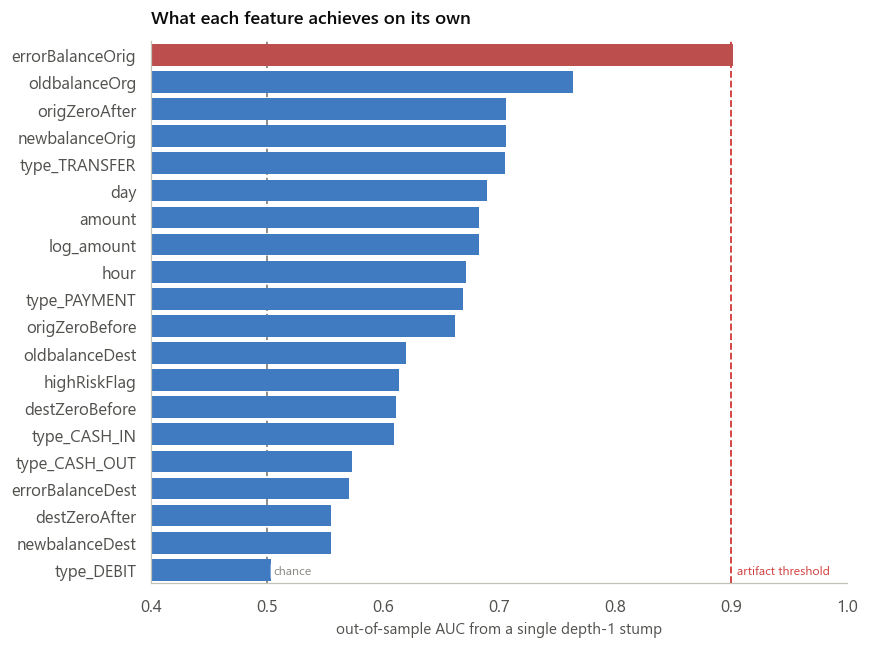

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# Accent the flagged features; the rest recede. Two colours, so the legend is
# unnecessary — the rule line and its label carry the meaning.
colors = [viz.STATUS["critical"] if f in suspicious else viz.CATEGORICAL[0]
          for f in auc_table["feature"]]

sns.barplot(auc_table, x="auc", y="feature", hue="feature",
            palette=colors, legend=False, ax=ax)

# Both labels sit at the baseline: the top of this axes is occupied by the
# longest bars, and a red label printed over a red bar is unreadable.
viz.annotate_reference(ax, 0.90, "artifact threshold", axis="x",
                       color=viz.STATUS["critical"], below=True)
viz.annotate_reference(ax, 0.50, "chance", axis="x", below=True)

ax.set(title="What each feature achieves on its own",
       xlabel="out-of-sample AUC from a single depth-1 stump", ylabel="",
       xlim=(0.4, 1.0))
viz.despine(ax)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "02_single_feature_auc")
plt.show()

## 5. Account reuse across the split

PaySim reuses destination accounts, so a model given the raw identifiers could memorise specific mule accounts rather than learn fraud behaviour. We drop `nameOrig` and `nameDest` (as Lokanan did), but the exposure is worth quantifying for the write-up.

In [9]:
overlap = S.account_overlap(df, split, column="nameDest")
for key, value in overlap.items():
    print(f"  {key:32s} {value:,.4f}" if isinstance(value, float) else f"  {key:32s} {value:,}")

E.save_json(overlap, "02_account_overlap")
print("\nBoth identifier columns are dropped before modelling — see features.py.")

  n_test_accounts                  625,839
  n_test_rows_with_seen_account    603,958
  fraction_test_rows_seen          0.6328

Both identifier columns are dropped before modelling — see features.py.


## 6. The ablation decision

Whatever the probe found, notebooks 03–06 run twice: once with the balance-error features and once without. The report then states its conclusions in the form *"CSL's advantage holds even when the simulator-artifact features are removed"* — which is a far stronger claim than one made on the full feature set alone, and it is the honest answer to a reviewer who points out that PaySim is synthetic.

In [10]:
full = FeatureBuilder(include_artifacts=True).fit(df.iloc[split.train])
ablated = FeatureBuilder(include_artifacts=False).fit(df.iloc[split.train])

decision = {
    "dropped_as_leakage": C.LEAK_COLUMNS,
    "dropped_as_identifiers": C.ID_COLUMNS,
    "flagged_as_artifacts": suspicious,
    "ablation_removes": ARTIFACT_FEATURES,
    "n_features_full": len(full.feature_names_),
    "n_features_ablated": len(ablated.feature_names_),
    "high_risk_cutoff": full.high_risk_cutoff,
}
E.save_json(decision, "02_feature_decision")

for key, value in decision.items():
    print(f"  {key:24s} {value}")
print("\nNext: 03_baselines.ipynb")

  dropped_as_leakage       ['isFlaggedFraud']
  dropped_as_identifiers   ['nameOrig', 'nameDest']
  flagged_as_artifacts     ['errorBalanceOrig']
  ablation_removes         ['errorBalanceOrig', 'errorBalanceDest']
  n_features_full          20
  n_features_ablated       18
  high_risk_cutoff         1619410.625

Next: 03_baselines.ipynb
